# Aula 06: tendências centrais com dados do Billboard

Este notebook acompanha a aula sobre tendências centrais. Ele foi escrito para ser usado como material de estudo: leia os textos, rode as células, altere alguns parâmetros e observe como as conclusões mudam.

Usaremos o dataset **Billboard Hits Songs Dataset**, disponível no Kaggle em `dem0nking/billboard-hits-songs-dataset`. Cada linha representa uma música e traz título, artista, gênero, data de lançamento, duração, álbum e popularidade.

## 1. Download do dataset

O código abaixo baixa a versão mais recente do dataset público no Kaggle. Em alguns ambientes, pode ser necessário instalar a biblioteca antes:

```bash
pip install kagglehub
```

A célula usa exatamente o identificador do dataset que será usado na aula.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dem0nking/billboard-hits-songs-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/ramosh/.cache/kagglehub/datasets/dem0nking/billboard-hits-songs-dataset/versions/3


## 2. Preparação do ambiente

Agora carregamos as bibliotecas que serão usadas na análise. O foco da aula não é programação avançada: as funções auxiliares abaixo servem apenas para deixar a tabela pronta para visualização.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

## 3. Leitura dos dados

O download do Kaggle retorna uma pasta. Vamos procurar o arquivo `.csv` dentro dela e carregar a tabela com `pandas`.

In [3]:
dataset_dir = Path(path)
csv_files = sorted(dataset_dir.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado na pasta baixada do Kaggle.")

csv_path = csv_files[0]
print("Arquivo usado:", csv_path.name)

raw = pd.read_csv(csv_path)
raw.head()

Arquivo usado: Iconic_Songs_Dataset.csv


,Title,Artist,Genre,ReleaseDate,Duration,Album,Popularity
0,Blinding Lights,The Weeknd,Pop,2024-01-05,3:22,After Hours,95
1,Levitating,Dua Lipa,Pop,2024-01-14,3:23,Future Nostalgia,93
2,Peaches,Justin Bieber ft. Daniel Caesar & Giveon,Pop,2024-02-12,3:18,Justice,91
3,Save Your Tears,The Weeknd,Pop,2024-02-18,3:36,After Hours,92
4,Good 4 U,Olivia Rodrigo,Pop,2024-03-05,2:58,SOUR,94


In [4]:
raw.shape, raw.columns.tolist()

((100, 7),
 ['Title',
  'Artist',
  'Genre',
  'ReleaseDate',
  'Duration',
  'Album',
  'Popularity'])

## 4. Análise descritiva básica da base

Antes de calcular média ou mediana, faça uma inspeção inicial. Ela responde perguntas simples, mas essenciais:

- quantas linhas e colunas existem?
- quais são as variáveis?
- há valores ausentes?
- quais colunas são numéricas?
- quais unidades aparecem na base?

In [5]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Title        100 non-null    object
 1   Artist       100 non-null    object
 2   Genre        100 non-null    object
 3   ReleaseDate  100 non-null    object
 4   Duration     100 non-null    object
 5   Album        98 non-null     object
 6   Popularity   100 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 5.6+ KB


In [6]:
raw.isna().sum()

Title          0
Artist         0
Genre          0
ReleaseDate    0
Duration       0
Album          2
Popularity     0
dtype: int64

In [7]:
raw["Genre"].value_counts()

Genre
Pop           59
Hip-Hop       26
Reggaeton      4
K-Pop          3
R&B            3
Afrobeats      2
Country        1
Dance          1
Electronic     1
Name: count, dtype: int64

## 5. Duração em minutos

A coluna `Duration` vem como texto no formato `minutos:segundos`, por exemplo `3:22`. Para calcular média, mediana e quartis, precisamos convertê-la para número.

In [8]:
def duration_to_minutes(duration):
    minutes, seconds = str(duration).split(":")
    return int(minutes) + int(seconds) / 60

songs = raw.copy()
songs["duration_min"] = songs["Duration"].map(duration_to_minutes)
songs["ReleaseDate"] = pd.to_datetime(songs["ReleaseDate"], errors="coerce")
songs.head()

,Title,Artist,Genre,ReleaseDate,Duration,Album,Popularity,duration_min
0,Blinding Lights,The Weeknd,Pop,2024-01-05,3:22,After Hours,95,3.366667
1,Levitating,Dua Lipa,Pop,2024-01-14,3:23,Future Nostalgia,93,3.383333
2,Peaches,Justin Bieber ft. Daniel Caesar & Giveon,Pop,2024-02-12,3:18,Justice,91,3.300000
3,Save Your Tears,The Weeknd,Pop,2024-02-18,3:36,After Hours,92,3.600000
4,Good 4 U,Olivia Rodrigo,Pop,2024-03-05,2:58,SOUR,94,2.966667


## 6. Pergunta motivadora

Como resumir a duração das músicas desse dataset?

Antes de responder com um número, vamos olhar para a distribuição. Essa é uma das regras práticas mais importantes da análise exploratória: **visualize antes de agregar**.

In [9]:
songs[["duration_min", "Popularity"]].describe().round(2)

,duration_min,Popularity
count,100.00,100.00
mean,3.37,91.71
std,0.60,3.81
min,1.92,84.00
25%,2.96,89.00
50%,3.37,92.00
75%,3.69,95.00
max,5.22,99.00


## 7. Histograma

O histograma divide a escala numérica em intervalos e conta quantas observações caem em cada intervalo. Ele ajuda a enxergar concentração, assimetria e valores extremos.

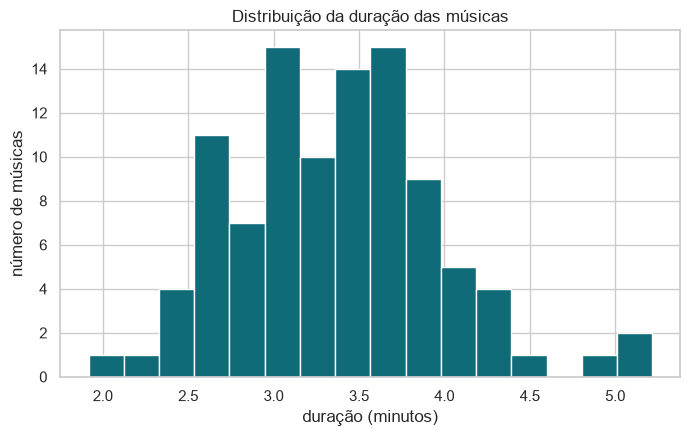

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(songs["duration_min"], bins=16, color="#0f6b78", edgecolor="white")
ax.set_title("Distribuição da duração das músicas")
ax.set_xlabel("duração (minutos)")
ax.set_ylabel("número de músicas")
plt.show()

## 8. A escolha dos bins importa

O número de bins é uma decisão de visualização. Poucos bins podem esconder detalhes; muitos bins podem sugerir ruído onde há apenas uma amostra pequena.

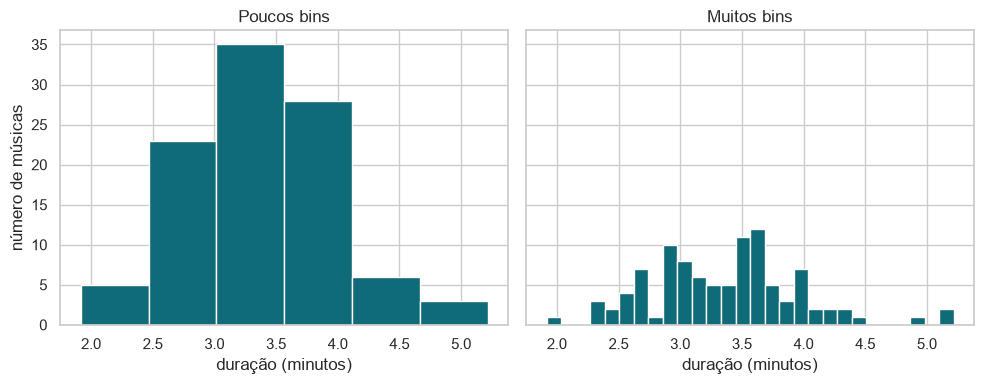

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, bins, title in zip(axes, [6, 28], ["Poucos bins", "Muitos bins"]):
    ax.hist(songs["duration_min"], bins=bins, color="#0f6b78", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("duração (minutos)")

axes[0].set_ylabel("número de músicas")
plt.tight_layout()
plt.show()

## 9. CDF empírica

A CDF empírica responde perguntas acumuladas: qual fração das músicas tem duração menor ou igual a certo valor?

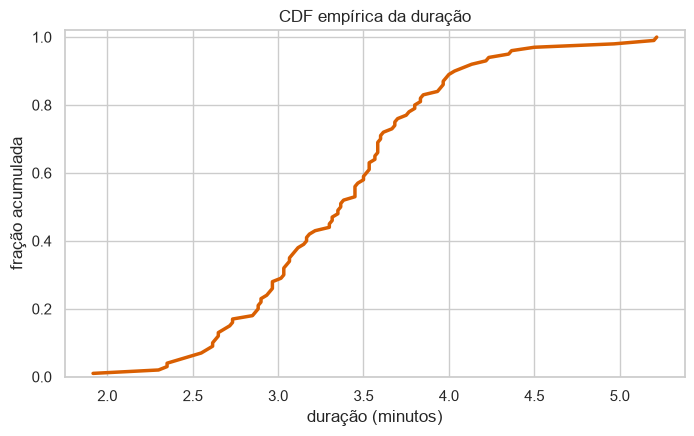

In [12]:
x = np.sort(songs["duration_min"].to_numpy())
y = np.arange(1, len(x) + 1) / len(x)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, y, color="#d95f02", linewidth=2.5)
ax.set_title("CDF empírica da duração")
ax.set_xlabel("duração (minutos)")
ax.set_ylabel("fração acumulada")
ax.set_ylim(0, 1.02)
plt.show()

In [13]:
limite = 4
frac_ate_4 = songs["duration_min"].le(limite).mean()
print(f"Fração de músicas com duração até {limite} minutos: {frac_ate_4:.1%}")

Fração de músicas com duração até 4 minutos: 89.0%


## 10. Média e mediana

A média usa todos os valores e é sensível a valores extremos. A mediana usa a posição central dos dados ordenados e costuma ser mais robusta quando há caudas ou outliers.

In [14]:
mean_duration = songs["duration_min"].mean()
median_duration = songs["duration_min"].median()

pd.Series({"média": mean_duration, "mediana": median_duration}).round(2)

média      3.37
mediana    3.37
dtype: float64

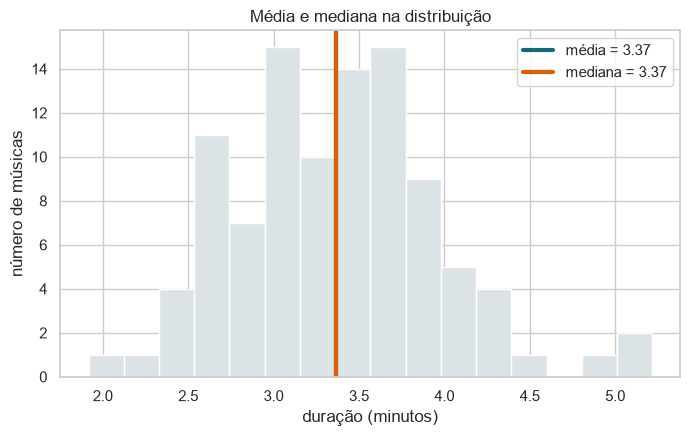

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(songs["duration_min"], bins=16, color="#dbe3e7", edgecolor="white")
ax.axvline(mean_duration, color="#0f6b78", linewidth=3, label=f"média = {mean_duration:.2f}")
ax.axvline(median_duration, color="#d95f02", linewidth=3, label=f"mediana = {median_duration:.2f}")
ax.set_title("Média e mediana na distribuição")
ax.set_xlabel("duração (minutos)")
ax.set_ylabel("número de músicas")
ax.legend()
plt.show()

## 11. Experimento com outlier

Vamos adicionar artificialmente uma música de 45 minutos. O objetivo é observar o comportamento dos resumos, não afirmar que esse ponto pertence ao dataset original.

In [16]:
song_long = pd.DataFrame({
    "Title": ["Faixa experimental de 45 minutos"],
    "Artist": ["Exemplo didático"],
    "Genre": ["Experimental"],
    "ReleaseDate": [pd.NaT],
    "Duration": ["45:00"],
    "Album": ["Exemplo"],
    "Popularity": [np.nan],
    "duration_min": [45.0],
})

songs_with_outlier = pd.concat([songs, song_long], ignore_index=True)

pd.DataFrame({
    "sem_outlier": [songs["duration_min"].mean(), songs["duration_min"].median()],
    "com_outlier": [songs_with_outlier["duration_min"].mean(), songs_with_outlier["duration_min"].median()],
}, index=["média", "mediana"]).round(2)

,sem_outlier,com_outlier
média,3.37,3.78
mediana,3.37,3.37


## 12. Quartis e boxplot

Quartis dividem os dados ordenados em quatro partes. O boxplot usa quartis para mostrar centro, dispersão e possíveis valores extremos.

In [17]:
songs["duration_min"].quantile([0.25, 0.50, 0.75]).round(2)

0.25    2.96
0.50    3.37
0.75    3.69
Name: duration_min, dtype: float64

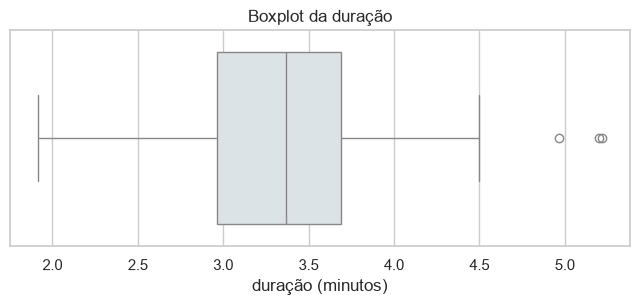

In [18]:
fig, ax = plt.subplots(figsize=(8, 2.8))
sns.boxplot(data=songs, x="duration_min", color="#dbe3e7", ax=ax)
ax.set_title("Boxplot da duração")
ax.set_xlabel("duração (minutos)")
plt.show()

## 13. Comparação por gênero

Quando existe uma variável categórica, podemos comparar distribuições entre grupos. Aqui, usamos `Genre` para comparar durações por gênero.

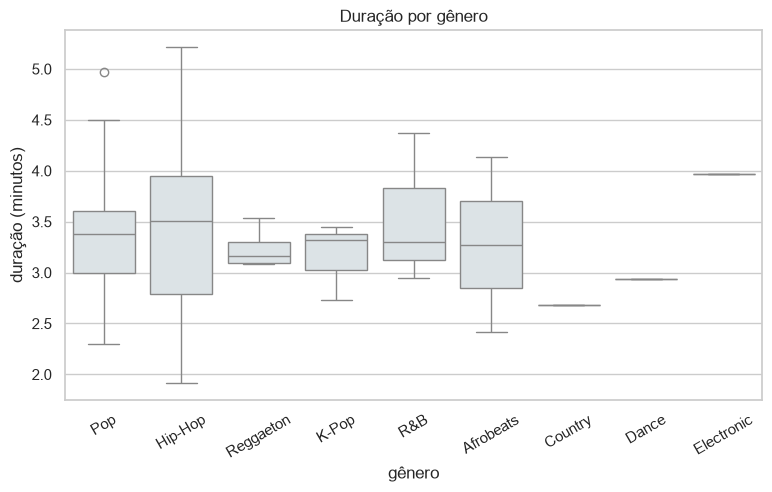

In [19]:
order = songs["Genre"].value_counts().index

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.boxplot(data=songs, x="Genre", y="duration_min", order=order, color="#dbe3e7", ax=ax)
ax.set_title("Duração por gênero")
ax.set_xlabel("gênero")
ax.set_ylabel("duração (minutos)")
ax.tick_params(axis="x", rotation=30)
plt.show()

## 14. Dispersão

Dois grupos podem ter centros parecidos, mas dispersões diferentes. Por isso, uma boa descrição combina medidas de centro com medidas de espalhamento.

In [20]:
pd.Series({
    "mínimo": songs["duration_min"].min(),
    "máximo": songs["duration_min"].max(),
    "intervalo": songs["duration_min"].max() - songs["duration_min"].min(),
    "variância": songs["duration_min"].var(),
    "desvio padrão": songs["duration_min"].std(),
}).round(2)

mínimo           1.92
máximo           5.22
intervalo        3.30
variância        0.37
desvio padrão    0.60
dtype: float64

## 15. Popularidade

O mesmo fluxo pode ser aplicado a outra coluna numérica. A variável `Popularity` é útil para reforçar que a técnica não depende da variável ser duração.

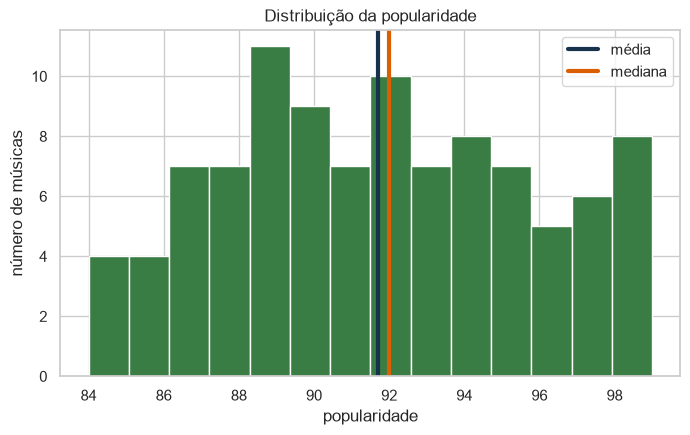

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(songs["Popularity"], bins=14, color="#3a7d44", edgecolor="white")
ax.axvline(songs["Popularity"].mean(), color="#17324d", linewidth=3, label="média")
ax.axvline(songs["Popularity"].median(), color="#d95f02", linewidth=3, label="mediana")
ax.set_title("Distribuição da popularidade")
ax.set_xlabel("popularidade")
ax.set_ylabel("número de músicas")
ax.legend()
plt.show()

In [22]:
songs["Popularity"].describe().round(2)

count    100.00
mean      91.71
std        3.81
min       84.00
25%       89.00
50%       92.00
75%       95.00
max       99.00
Name: Popularity, dtype: float64

## 16. Fechamento

Ao resumir uma distribuição, evite começar pela fórmula. Comece pela pergunta:

- Qual variável estou resumindo?
- Qual é a unidade de medida?
- Como é a forma da distribuição?
- Há assimetria ou valores extremos?
- Média e mediana contam a mesma história?
- O resumo escolhido comunica bem o que eu quero dizer?

## Exercícios para estudo

1. Refaça o histograma com `bins=8`, `bins=20` e `bins=40`. O que muda?
2. Calcule a fração de músicas com duração até 3 minutos.
3. Compare média e mediana de `duration_min` por `Genre`.
4. Escolha dois gêneros e compare seus boxplots.
5. Escreva um parágrafo curto respondendo: qual número você usaria para comunicar uma duração típica nesse dataset? Por quê?
6. Repita a análise para `Popularity` e compare com a análise de duração.